# Brock s07_s08 (20260708) — automatic bout scoring from button-press events

run via (from your command line, like 'cmd' in windows)
`uv run jupyter lab`
then open this file and run it. 

## Notes about this session
The 20260708 session (s07/s08) has no hand-scored `ExpTrialBounds.mat`. Instead the experimenter pressed the **event** sensor's button at the start and stop of every movement bout, so the bounds live in the `.h5` `Annotations` stream ('Start'/'Stop').

## Pipeline for all sessions
8 steps A-H, and a playground (Section I) to help students get comfy with the data organization:

- **A. From event clicks → snip into trials** —

  `automatically_score_movements_from_events()`
  Use clicks to define trials. Stops must occur within a maximum `BOUNDING_WINDOW_S`, and we clean 1) Restarts (double-pressed
  Starts), 2) Orphan Stops (no start), and suspiciously short pairs.
  
- **B. Condition table** — `load_condition_table()` parses the trialtable CSV and
  write package size numerically (ring=1, small=2, medium=3, large=4; not totally necessary, just a habit when variables are essentially continuous in a variable [here it's package mass]).

- **C. Align snips to the trial table**
  `align_snips_to_trial_table()` measures each snip's walked distance
  from the foot IMUs (single-foot mechanization, max horizontal excursion, best foot
  wins and names the walker), expands the table into the expected bout sequence
  (each trial × 2 reps × 2 walkers), and sequence-aligns measured vs expected distance
  so **missed / skipped trials fall out as unmatched expected bouts**.
  `assign_walkers_by_protocol()` then fixes *who* walked each bout from the
  protocol order (`FIRST_WALKER` walks first in rep 1; rep 2 flips).

- **D. Why are trials missing**
  Before doing manual scoring, we chat about what errors can happen in a trial.

- **E. Save Results so far**
  We always save these raw data first. Manual editing does not change these original raw data values, so we can always re-score manually.
  
- **F. Per-trial inspection svg generation**
  For each trial generate summary figures. Use them in a separate window to decide which trials need manual scoring.

- **G. Manually correct trials — or load corrections saved earlier**
  G0 picks the mode (`LOAD_PREVIOUS_MANUAL_SCORING`). Scoring: G1 checks that your
  browser can do interactive figures, then G2 (drag) / G3 (click) — every Save
  writes the results immediately. Loading: G1–G3 are skipped.

- **H. Compare automatic vs corrected**
  Table of changed bouts, plus the automatic and corrected omnibus figures (saved as SVG).

- **I. Student playground**
  This section is meant for students to get more comfortable with the actual data itself. there are a list of functions that are key here, each have their own cell. They cover plotting trial data against type, doing inertial navigation/mechanization on a specific snipped trial, and other key 'steps' haha. 

## There are 4 places you need to edit for a new trial (sorry, they're slightly scattered)
### EDIT HERE 1/4: the file name stuff  
### EDIT HERE 2/4: do you have old manual scoring you'd like to reload?  
### EDIT HERE 3/4: what trials need interactive scoring (they have scored data, but you think it's not correct)  ### EDIT HERE 3/4: what trials need manual scoring (required for completely-missed trials)  

## End results — what to look at, and where

Output files are written in the data directory by default (the folder holding `H5_FILE`),
not in the git repo. They are prefixed with the `<tag>` = `SESSION_TAG` (here `s07_s08`).

**1. Figures** — `figures/<tag>/`

| File | Made by | What it shows |
| --- | --- | --- |
| `brock_<tag>_trial<N>_rep<R>_viz.svg` | F | **automatic** scoring, one per trial-rep: foot-speed overview of both people + each bout's overhead map, \|A\|, foot speed, step speed |
| `brock_<tag>_trial<N>_rep<R>_viz_manual.svg` | G (each Save) | the same figure **with manual corrections** — only for the trial-reps that needed correcting |
| `brock_<tag>_omnibus_auto.svg` | H | whole session: button presses + bout distances, **automatic** windows |
| `brock_<tag>_omnibus_plus_manual.svg` | H | the same **with the manual corrections** applied (only if there are any) |

**2. Tables (CSV)** — `cached data/`

| File | Made by | What it holds |
| --- | --- | --- |
| `brock_<tag>_auto_aligned.csv` | E | the **automatic** result: one row per expected bout (trial, rep, bout, walker, start/stop, expected vs measured distance, reaction time). Never overwritten by manual scoring. |
| `brock_<tag>_manual_rescore.csv` | G (each Save) | just **your corrections**: one row per corrected trial / rep / person with the new `start_s`, `stop_s`. Share this file to share your scoring; G0 can load it. |
| `brock_<tag>_manual_aligned.csv` | G (each Save) or G0 (load) | the **final table**: the automatic result with every correction applied and distances re-measured (`manual` = True on corrected bouts). Use this one for analysis. |


In [3]:
# --- Google Colab setup (safe to run anywhere: it is a NO-OP locally) -------
# NO Google permissions are requested: the data comes in through link-shared
# file downloads, and results go out as a browser download (last cell).
#
# LAB SETUP (once, by the data owner): in Google Drive, right-click the
# session .h5 and the trialtable .csv -> Share -> 'Anyone with the link'
# (Viewer) -> Copy link, and paste the two links below. Students need nothing
# but this notebook's URL after that.
import os, sys
IN_COLAB = 'google.colab' in sys.modules

H5_URL = 'https://drive.google.com/file/d/1-y5Qdlx3qzdhALeVndsKQ030P8Exphxh/view?usp=drive_link'
TRIALTABLE_URL = 'https://drive.google.com/file/d/1hdEXyHFlY7jtnxz6l7sOufsx8_IKOiFe/view?usp=drive_link'

if IN_COLAB:
    if not os.path.isdir('/content/stride_estimation_imu'):
        !git clone -q https://github.com/jeremydwong/stride_estimation_imu.git /content/stride_estimation_imu
    %cd /content/stride_estimation_imu/notebooks
    !pip install -q gdown ipympl
    from google.colab import output
    output.enable_custom_widget_manager()   # lets the interactive cells work
    import gdown
    os.makedirs('/content/brock_data', exist_ok=True)
    for url, name in ((H5_URL, None), (TRIALTABLE_URL, None)):
        if url.startswith('http'):
            gdown.download(url=url, output='/content/brock_data/', fuzzy=True)
        else:
            print('!! paste the Drive share links above first (ask the lab)')


In [4]:
# --- setup / configuration ---
%matplotlib inline
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../src'))   # stride_imu + brock_functions
import stride_imu as imu
from brock_functions import (load_events, automatically_score_movements_from_events,
                             load_condition_table, load_available_feet,
                             align_snips_to_trial_table, explain_missed, bout_spacing,
                             save_trial_figures, manual_correct,
                             apply_manual_rescore, refresh_manual_distances, plot_omnibus,
                             assign_walkers_by_protocol)

# --- session-specific configuration: EDIT HERE 1/4: file stuff---
SESSION_TAG = 's07_s08'

# os.environ.get(NAME, default) = use the environment variable when one
# is set, else the default path. It never SETS the variable - it is a
# hook so a batch run can point this notebook at other files unedited.
# where the session data lives: the gdown folder on Colab, Dropbox locally
DATA_DIR = ('/content/brock_data' if 'google.colab' in sys.modules else
            '/Users/jeremy/Dropbox/Treadmill Brock 2025/imu data')
H5_FILE = os.environ.get('STRIDE_DATA_FILE',
    os.path.join(DATA_DIR, 'imuData_'+SESSION_TAG+'_20260708.h5'))

# CONDITION CSV is needed. 
XLSX_FILE = 'SubInfo2.xlsx' # ONLY used if we set BUILD_TRIALTABLE_FROM_XLSX = True. Otherwise, we use the CSV file below.
CONDITION_CSV = []  # we choose whether to build it or use one already existing, below. 
BUILD_TRIALTABLE_FROM_XLSX = True    # set True to use this path
if BUILD_TRIALTABLE_FROM_XLSX:
    SHEET = SESSION_TAG                          # make sure they match!
    
    from brock_functions import list_xlsx_sheets, trialtable_from_xlsx
    if IN_COLAB:
        from google.colab import files
        up = files.upload()           # choose your SubInfo2*.xlsx
        xlsx = next(iter(up))
    else:
        xlsx = os.path.join(DATA_DIR, XLSX_FILE)
    print('sheets in this workbook:', list_xlsx_sheets(xlsx))
    CONDITION_CSV = trialtable_from_xlsx(xlsx, SHEET or SESSION_TAG, DATA_DIR)
    print('trialtable written ->', CONDITION_CSV)
else:
    CONDITION_CSV = os.environ.get('STRIDE_TRIALTABLE_FILE',
        os.path.join(DATA_DIR, 'trialtable_20260708.csv'))

# Walking order (protocol): in rep 1 (the first pass through the 48 trials)
# FIRST_WALKER walks bout 1 and the other person bout 2; rep 2 flips it.
# Used in C to fix who walked each bout ('a' = the *_a feet, 'b' = *_b).
FIRST_WALKER = 'a'

# all generated tables live beside the imu data, next to figures/
CACHE_DIR = os.path.join(os.path.dirname(H5_FILE), 'cached data')
os.makedirs(CACHE_DIR, exist_ok=True)
ALIGNED_CSV = os.path.join(CACHE_DIR, f'brock_{SESSION_TAG}_auto_aligned.csv')
RESCORE_CSV = os.path.join(CACHE_DIR, f'brock_{SESSION_TAG}_manual_rescore.csv')

# Analysis variables you may wish to tune, to help with matching up our trials. 
BOUNDING_WINDOW_S = 30.0   # a Start and its Stop must fall within this window
MIN_BOUT_S        = 1.5    # shorter pairs are flagged as likely accidental presses

# Recover bouts the experimenter STARTED but forgot to end: close them where
# the walker plants both feet (the hand-off stance). INFER_STOPS = False for
# clicks-only.
INFER_STOPS      = True
INFER_MIN_BOUT_S = 2.0     # ignore a settle this soon after the Start
QUIET_SECONDS    = 0.75    # walker-pair stance that ends the bout: must be
                           # shorter than a hand-off stance (~0.9 s observed)
                           # and longer than within-gait double-stance (~0.3 s)

# Alignment: we optimally figure out how to jump skipped trials to align our found
# bouts in the IMU data with our csv file. We penalise a match that puts the two bouts of ONE
# trial minutes apart. 0 = distance-only (the old behaviour).
TIME_WEIGHT = 0.6
pd.set_option('display.width', 160)


sheets in this workbook: ['s01_s02', 's03_s04', 's05_s06', 's07_s08', 's09_s10', 'Summary Stats']
trialtable written -> /Users/jeremy/Dropbox/Treadmill Brock 2025/imu data/trialtable_20260708.csv


## A. Events → snips

Pair the button presses (literally return an (n,2) matrix for n start presses. Every paired start-stop must:  
- happen within some maximum time ('bounding_window_s', 30s)
- be greater than some minimu time (min_bout_t of 1.5s by default)
- be succeeded by a 'quiet_seconds' where the feet are stable (0.75s)

We here log a few different kinds of event curiosities:  
- `restarts` are Starts superseded by a later Start before any Stop (the bout keeps the **last** Start)
- `orphan_stops` had no viable Start (i.e. a stop, but no start within 30s, the 'bounding_window_s')
- `short` flags sub-`MIN_BOUT_S` pairs

**Forgotten Stop clicks (`INFER_STOPS`).** Sometimes bouts are started and never ended, and the next press is another `Start`. Without
inference we have to decide which start is true.  
With `INFER_STOPS = True`, `infer_stop_from_quiet()` closes it at the end of the **first sustained walk**, defined as:  
- where [per person] gaps in steps are all shorter than `QUIET_SECONDS`  
- thus the walk ends where the walker plants both feet for `QUIET_SECONDS` 

Notes:  
- The search runs only up to the next button press so an inferred bout can never overlap with the following one  
- A Start with no settle before that limit is still left unpaired rather than guessed.  


feet available: ['left_foot_a', 'right_foot_a', 'right_foot_b', 'left_foot_b'] @ 128 Hz
192 Starts + 189 Stops -> 191 snips (5 with an inferred stop)
unrecovered duplicate Starts: 0 at t = []
orphan Stops: [1525.7 6421.5 6421.8]
short (<1.5s) snips: [] -> []
inferred-stop durations: median 9.6 s vs 6.8 s for clicked bouts


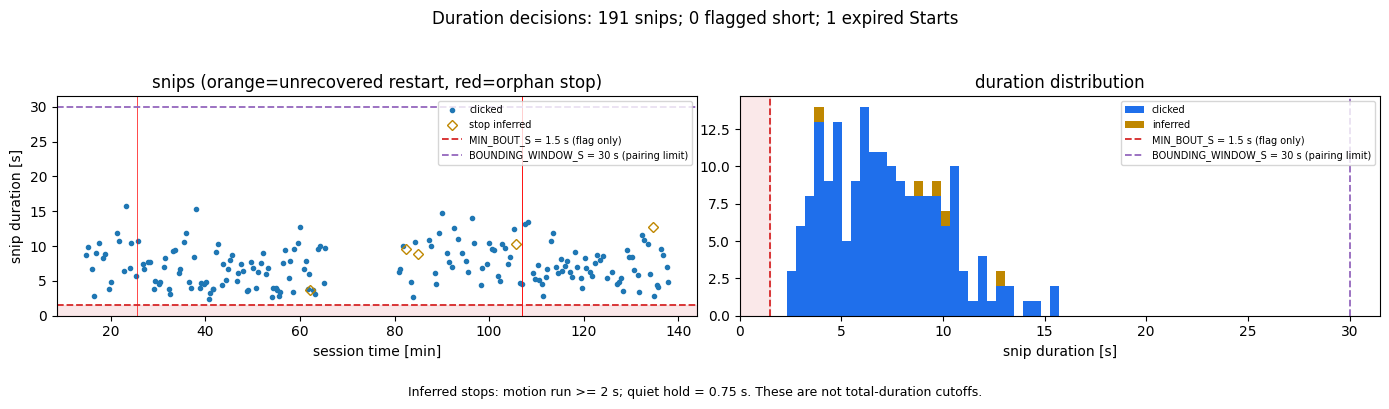

In [5]:
feet = load_available_feet(H5_FILE)
print('feet available:', list(feet), f'@ {1/next(iter(feet.values())).period:.0f} Hz')

events = load_events(H5_FILE)
snips, report = automatically_score_movements_from_events(
    events, bounding_window_s=BOUNDING_WINDOW_S, min_bout_s=MIN_BOUT_S,
    data=feet if INFER_STOPS else None, infer_stops=INFER_STOPS,
    quiet_seconds=QUIET_SECONDS, infer_min_bout_s=INFER_MIN_BOUT_S)
inferred = report['inferred']

### below, we print some results and plot to screen the bout durations. We're looking for any wild outliers, and visualizing where  
durations = snips[:, 1] - snips[:, 0]
print(f"{report['n_start']} Starts + {report['n_stop']} Stops -> {report['n_snips']} snips "
      f"({report['n_inferred']} with an inferred stop)")
print(f"unrecovered duplicate Starts: {len(report['restarts'])} at t = {np.round(report['restarts'], 1)}")
print(f"orphan Stops: {np.round(report['orphan_stops'], 1)}")
print(f"short (<{MIN_BOUT_S}s) snips: {report['short']} -> {np.round(snips[report['short']], 1).tolist()}")
if report['n_inferred']:
    print(f"inferred-stop durations: median {np.median(durations[inferred]):.1f} s "
          f"vs {np.median(durations[~inferred]):.1f} s for clicked bouts")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 4))
ax0.plot(snips[~inferred, 0] / 60, durations[~inferred], '.', label='clicked')
ax0.plot(snips[inferred, 0] / 60, durations[inferred], 'D', mfc='none',
         color='#bf8700', ms=5, label='stop inferred')
for t in report['restarts']:
    ax0.axvline(t / 60, color='orange', lw=0.5)
for t in report['orphan_stops']:
    ax0.axvline(t / 60, color='red', lw=0.5)
ax0.set_xlabel('session time [min]'); ax0.set_ylabel('snip duration [s]')
ax0.set_title('snips (orange=unrecovered restart, red=orphan stop)')

ax1.hist([durations[~inferred], durations[inferred]], bins=30, stacked=True,
         color=['#1f6feb', '#bf8700'], label=['clicked', 'inferred'])
ax1.set_xlabel('snip duration [s]'); ax1.set_title('duration distribution')
# These are duration decisions; short snips remain in the data, flagged.
for ax, vertical in ((ax0, False), (ax1, True)):
    line = ax.axvline if vertical else ax.axhline
    shade = ax.axvspan if vertical else ax.axhspan
    shade(0, MIN_BOUT_S, color='tab:red', alpha=.10)
    line(MIN_BOUT_S, color='tab:red', ls='--', lw=1.3,
         label=f'MIN_BOUT_S = {MIN_BOUT_S:g} s (flag only)')
    line(BOUNDING_WINDOW_S, color='tab:purple', ls='--', lw=1.3,
         label=f'BOUNDING_WINDOW_S = {BOUNDING_WINDOW_S:g} s (pairing limit)')
    ax.legend(fontsize=7, loc='upper right')
ax1.set_xlim(left=0)
ax0.set_ylim(bottom=0)
fig.suptitle(f'Duration decisions: {len(durations)} snips; '
             f'{np.sum(durations < MIN_BOUT_S)} flagged short; '
             f"{len(report['expired_starts'])} expired Starts")
# Motion-run length and quiet hold are NOT thresholds on total snip duration.
inference_note = (f'Inferred stops: motion run >= {INFER_MIN_BOUT_S:g} s; '
                  f'quiet hold = {QUIET_SECONDS:g} s. These are not total-duration cutoffs.'
                  if INFER_STOPS else 'Inferred stops disabled.')
fig.text(.5, .015, inference_note, ha='center', fontsize=9)
plt.tight_layout(rect=(0, .07, 1, .94))


## B. Condition table

48 trials; `package_code` transcribes ring=1, small=2, medium=3, large=4. The rep
status columns carry the experimenter's notes (interruptions etc.) — useful when
interpreting alignment anomalies below.


In [6]:
conditions = load_condition_table(CONDITION_CSV)
print(conditions[conditions.rep1_status.ne('') | conditions.rep2_status.ne('')]
      [['trial', 'distance_m', 'package', 'rep1_status', 'rep2_status']].to_string(index=False))
conditions.head(8)


 trial  distance_m package                        rep1_status                                           rep2_status
     2        12.0    ring                                                           Participant 2 did not hold box
     5        12.0  medium                                                     participant 2 started before command
     6         5.0  medium             Started before command                                                      
     8         8.0   large                                                       large delay before started walking
    12        12.0   small             Started before command                    large delay before started walking
    14         5.0   large                                                                        late on end event
    19        12.0   small                                    uncertaintiy on second walking trial  missed end stop
    21        12.0  medium                  late on end event           

,trial,rand,distance_m,package,pose,rep1_status,rep2_status,Notes,package_code
0,1,0.248002,5.0,ring,ground,,,NaN,1
1,2,0.844924,12.0,ring,held out,,Participant 2 did not hold box,NaN,1
2,3,0.240843,2.5,ring,held out,,,NaN,1
3,4,0.927204,12.0,ring,waist,,,NaN,1
4,5,0.716436,12.0,medium,held out,,participant 2 started before command,NaN,3
5,6,0.737267,5.0,medium,held out,Started before command,,NaN,3
6,7,0.146732,12.0,ring,ground,,,NaN,1
7,8,0.683027,8.0,large,held out,,large delay before started walking,NaN,4


## C 1 of 2: Measure snip distances

This runs single-foot mechanization on every foot × snip (a few minutes). The
expected sequence is **rep-major** (confirmed against the data): the whole 48-trial
table is walked once (rep 1, 2 bouts per trial — one per walker), then again (rep 2).
The alignment tolerates extra snips and missing bouts.

**Who walked which bout** is then fixed from the protocol: in rep 1 `FIRST_WALKER`
walks bout 1 and the other person bout 2, and rep 2 flips it
(`assign_walkers_by_protocol`). The alignment's own guess — the foot that moved
farthest — can be fooled on short 2.5 m trials, where a *standing* foot's
integration drift out-travels the real walk. The original guess is kept in the
`walker_auto` column; `walker_changed` marks the bouts that were corrected.


In [7]:
# drop the flagged sub-MIN_BOUT_S pairs (accidental presses) before aligning
keep = np.setdiff1d(np.arange(len(snips)), report['short'])
res = align_snips_to_trial_table(feet, snips[keep], conditions, inferred=inferred[keep],
                        time_weight=TIME_WEIGHT)
# Who walked each bout: the alignment guesses from the farthest-moving foot,
# which standing-foot drift can fool on short trials. Fix it from the
# protocol's walking order (FIRST_WALKER, set in the configuration cell).
res = assign_walkers_by_protocol(feet, res, first_walker=FIRST_WALKER)
print(f"walker fixed by protocol order on {int(res['aligned']['walker_changed'].sum())} bouts")
# Keep res['aligned'] as the untouched automatic baseline for comparisons.
aligned = res['aligned'].copy(deep=True)
err = aligned['distance_error_m'].abs()
print(f"matched {aligned['snip'].notna().sum()}/{len(aligned)} expected bouts; "
      f"median |distance error| {err.median():.2f} m (95th pct {err.quantile(0.95):.2f} m)")
print(f"of the matched bouts, {int(aligned['inferred'].sum())} had an inferred stop")


walker fixed by protocol order on 42 bouts
matched 189/192 expected bouts; median |distance error| 0.47 m (95th pct 1.08 m)
of the matched bouts, 5 had an inferred stop


## C 2 of 2. Omnibus figure — button presses and walks across experiment time

The x axis is real experiment time (the top axis keeps the expected bout-sequence index / trial), and button
presses are drawn at bottom: **Start = up tick, Stop = down tick** — direction as
well as colour. Distances are noted in colour as well: Grey = expected,
blue = measured, red X = missed. Only two annotation types exist in these files
(`Start`/`Stop`, all from the `event` sensor).

Missed bouts have no snip, so each is placed at a time **interpolated** between its
matched neighbours. Those X's are then readable against the button presses, in that if
presses sit under an X, the bout happened and the pairing/alignment rejected it; if the
band is empty under an X, the button was simply never pressed there.

**Pairing check (the 'uneven dots' flag):** each trial-rep should give exactly two bouts,
one per walker, at the same distance. The two are joined by a connector — **grey solid
when the pair is complete, red dashed when it isn't**.

`plot_omnibus(feet, events, res, aligned=None, report=report)` is the reusable
figure function. Omit `aligned` for the automatic baseline; pass a corrected
table to show saved adjustments. It returns `(fig, axes, plotted_table)`.
The save-and-compare cell in section H calls the same function after rescoring.

`missed` means an expected bout with no matching snip; `extra` means a snip
with no matching expected bout. Their counts appear below. Full diagnostic
tables remain available as `res["missed"]` and `res["extra"]`.


Automatic alignment: 3 missed expected bouts; 2 extra snips
108 bouts with negative reaction (median reaction -0.14 s)
trial-reps not yielding a clean pair: 2
  trial  1 rep 1: 0 of 2 bouts matched
  trial 37 rep 2: 1 of 2 bouts matched


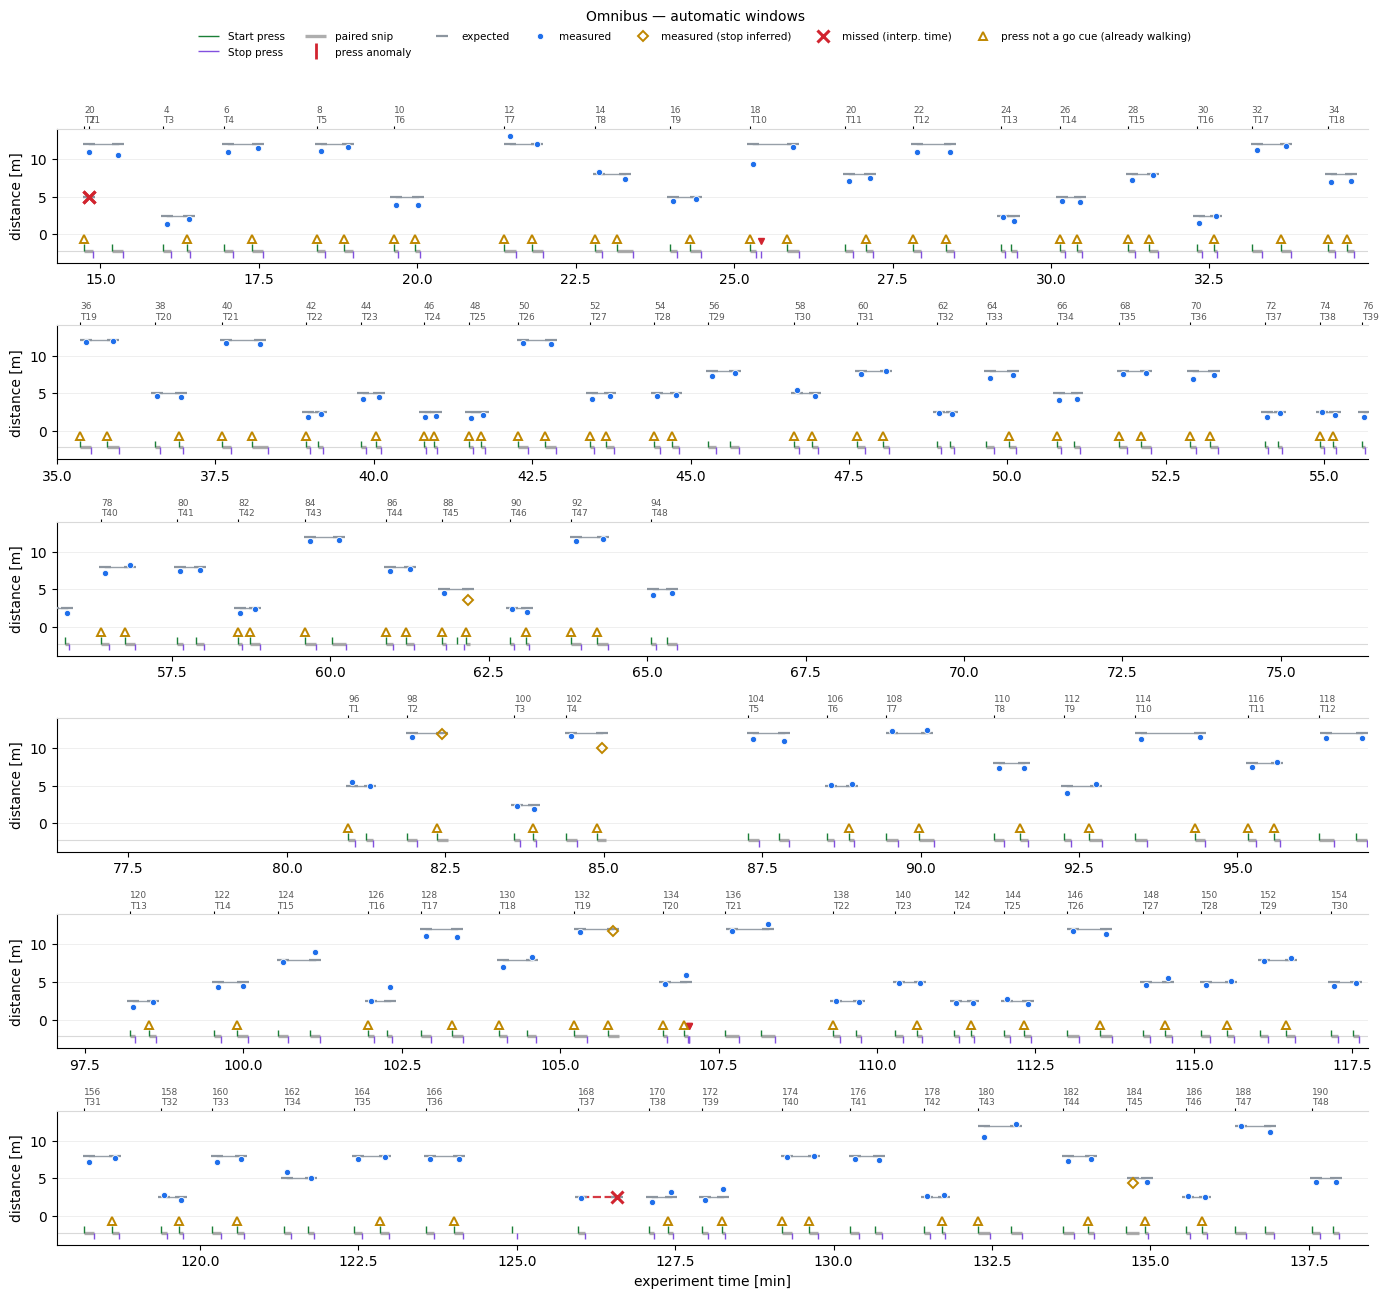

In [8]:
# Alignment diagnostics belong with the omnibus; no separate sequence plot.
print(f"Automatic alignment: {len(res['missed'])} missed expected bouts; "
      f"{len(res['extra'])} extra snips")

# reaction time per bout (Start press -> snug gait start; ~10 s to compute).
# NEGATIVE = the walker was already going: the press was not a go cue -
# marked with an orange open triangle under the bout in the figure below.
from brock_functions import estimate_reaction_s
if 'reaction_s' not in aligned:
    aligned['reaction_s'] = estimate_reaction_s(feet, aligned)
print(f"{(aligned['reaction_s'] < 0).sum()} bouts with negative reaction "
      f"(median reaction {aligned['reaction_s'].median():+.2f} s)")

fig, axes, _ = plot_omnibus(feet, events, res, report=report, rows=6)

counts = imu.pair_status(aligned)
uneven = {k: v for k, v in counts.items() if v != 2}
print(f'trial-reps not yielding a clean pair: {len(uneven)}')
for (trial, rep), n in sorted(uneven.items()):
    print(f'  trial {trial:>2} rep {rep}: {n} of 2 bouts matched')


## D. Why are trials missing? Understanding missing bouts 
(In preparing for manual scoring, we document the logic)

*(The worked examples below — trials 37-40, trial 2 rep 2, etc. — are from the
s03/s04 20260622 session where this method was developed; the logic applies
unchanged here.)*

`align_snips_to_expected()` is a **Needleman-Wunsch global alignment** (fancy words!) on trial distance. It depends on having distances that vary from trial to trial. Sorta like bumps on a fingerprint. 
The way the algorithm works is to calculate a `match cost` = `|measured - expected| / max(...)`  
while skipping either an expected bout ('missed') or a measured snip ('extra') costs a flat `gap_penalty` (0.55). 

It returns the single cheapest path through the cost matrix to align our d.

**Identifiability caveat — important.** Because distance is the only signal, within a run
of equal-distance trials the alignment recovers *how many* bouts are missing but **not
which ones**. Trials 37-40 rep 1 are all 12 m: the table below attributes the gap to
trial 37/38, but that is a traceback tie-break (ties drift gaps toward the start of a
run), not evidence. The defensible claim is *'3 of the 8 twelve-metre bouts across trials
37-40 rep 1 are missing'*. Run boundaries are firm only where the distance changes.

**Time consistency (`TIME_WEIGHT`).** Distance alone is not enough: with a pure
distance cost the aligner happily placed the two bouts of trial 2 rep 2 **322 s**
apart (and trial 48 rep 1 **403 s** apart), bridging a hole while orphaning the five
genuine walks inside it as 'extra'. The two walkers of a rep actually go ~13 s apart,
so a diagonal step now also pays when it implies an impossible within-trial gap.
The penalty applies **only within a trial-rep** - real between-trial transitions vary
far too much to police, and penalising them made the alignment drop good matches
instead of fixing bad ones. This recovered trials 3-4 of rep 2 around t = 87-88 min.

`explain_missed()` adds two signals the aligner never sees:

- **presses in the gap** — 0 means the button was never pressed there; an odd count means
  one press of a pair went missing.
- **room in the clock** — the gap length against the session's own between-trial pacing.
  A gap no longer than a normal transition has no room for an extra walk, so a red X
  there is more likely an alignment artifact than a genuinely missed bout.

**A test that did NOT work, recorded so it is not retried:** foot motion during the gap.
It looks decisive but is not — the participants walk *back* to the start between trials,
so control transition gaps contain a median **11.2 m** of walking versus **9.1 m** in the
suspect gaps. `walked_m` is reported for context only and is excluded from the verdict.


In [9]:
spacing = bout_spacing(aligned)
print(f"session pacing: {spacing['within_trial_s']:.0f} s between the two walkers of a rep, "
      f"{spacing['between_trial_s']:.0f} s between trials")

why = explain_missed(aligned, events, data=feet, spacing=spacing)
print(why[['trial', 'rep', 'bout', 'distance_m', 'gap_s', 'n_presses', 'presses',
           'walked_m', 'verdict']].round(1).to_string(index=False))
print()
print(why['verdict'].value_counts().to_string())

# sanity check: the two bouts of a trial-rep go one walker after the other (~13 s).
# A matched pair stretched far beyond that means the alignment bridged a hole
# instead of using the walks inside it - the failure the time term exists to stop.
m = aligned.dropna(subset=['start_s'])
pair_gaps = pd.DataFrame(
    [(t, r, g['start_s'].iloc[1] - g['stop_s'].iloc[0])
     for (t, r), g in m.groupby(['trial', 'rep']) if len(g) == 2],
    columns=['trial', 'rep', 'gap_s'])
print()
print(f"within-trial bout gap: median {pair_gaps.gap_s.median():.0f} s; "
      f"{(pair_gaps.gap_s > 60).sum()} pair(s) over 60 s")
print(pair_gaps.nlargest(3, 'gap_s').round(0).to_string(index=False))

session pacing: 15 s between the two walkers of a rep, 36 s between trials
 trial  rep  bout  distance_m  gap_s  n_presses presses  walked_m                                                verdict
     1    1     1         5.0    NaN          0               NaN no press, no room in clock - likely alignment artifact
     1    1     2         5.0    NaN          0               NaN no press, no room in clock - likely alignment artifact
    37    2     2         2.5   61.2          0               5.9   no press + unexplained extra time - likely real miss

verdict
no press, no room in clock - likely alignment artifact    2
no press + unexplained extra time - likely real miss      1

within-trial bout gap: median 15 s; 0 pair(s) over 60 s
 trial  rep  gap_s
    10    2   46.0
    10    1   30.0
    12    1   24.0


## E: save cached results
Just save the aligned table by calling to_csv. 

In [10]:
# save the aligned table within the 'cached data' directory
aligned.to_csv(ALIGNED_CSV, index=False)
print(f'wrote {ALIGNED_CSV},', len(aligned), 'rows')
aligned[aligned['snip'].isna() | aligned['distance_error_m'].abs().gt(1.5)]

wrote /Users/jeremy/Dropbox/Treadmill Brock 2025/imu data/cached data/brock_s07_s08_auto_aligned.csv, 192 rows


,trial,rep,bout,distance_m,package,package_code,status,snip,start_s,stop_s,duration_s,measured_m,walker,inferred,distance_error_m,reaction_s,jumped_gun,walker_auto,walker_changed
0,1,1,1,5.0,ring,1,,NaN,NaN,NaN,NaN,NaN,,False,NaN,NaN,False,,False
1,1,1,2,5.0,ring,1,,NaN,NaN,NaN,NaN,NaN,,False,NaN,NaN,False,,False
18,10,1,1,12.0,large,4,,16.0,1514.922119,1520.688162,5.766043,9.426391,right_foot_a,False,-2.573609,-0.281250,True,right_foot_a,False
103,4,2,2,12.0,ring,1,,102.0,5093.523682,5102.398682,8.875000,10.074899,right_foot_a,True,-1.925101,-2.812500,True,right_foot_a,False
127,16,2,2,2.5,medium,3,,126.0,6136.089854,6141.066853,4.976999,4.315569,left_foot_a,False,1.815569,0.023438,False,left_foot_b,True
169,37,2,2,2.5,medium,3,,NaN,NaN,NaN,NaN,NaN,,False,NaN,NaN,False,,False
180,43,2,1,12.0,large,4,,179.0,7936.506262,7948.164159,11.657897,10.459144,left_foot_b,False,-1.540856,-0.851562,True,left_foot_b,False


## F. Per-trial visualization figures for inspection
Note: this section actually takes time, maybe about a minute or so, to generate the figures!  

One SVG per trial **repetition** (the two reps of a trial are usually far apart
in time). On top, a foot-speed time history of all four feet around that rep's
bouts (person A black, B green, right foot dashed; each snip shaded) — the
quickest check that the snips sit on the actual walks. Below it, one block per
bout: overhead foot map on the left, raw |A| / foot speed / step speed on the
right. Written to `figures/s07_s08/brock_s07_s08_trial<N>_rep<R>_viz.svg`
(folder created as needed).
This runs the two-IMU stride pipeline per bout, so expect several minutes for
all 48 trials; set `FIG_TRIALS` to a short list (e.g. `[1, 2]`) while testing.


Both gait boundaries are now snugged using foot speed: before the first strong swing and after the last strong swing. The final stride/step calculation is rerun on the trimmed window. Start/Stop button lines remain visible for comparison; the reported gait duration ends at the snug gait end. The absolute-sample axis shows only its first and last round in-range ticks.

The solid purple **Snug end** line is the detected end of walking. The dashed grey **Stop press** line is the original button press. A shaded interval and the **end trimmed … s** annotation show the difference explicitly. Rerun the export cell to refresh files in `figures/`; it reloads the helpers to avoid exporting with stale notebook code.

In [13]:
# Reload shared helpers so rerunning this cell after a code update does not
# silently export figures using the old functions held in the notebook kernel.

import importlib
import stride_imu.inertial as inertial_backend
import stride_imu.plotting as plotting_backend
import brock_functions
for module in (inertial_backend, plotting_backend, imu, brock_functions):
    importlib.reload(module)

FIG_TRIALS = None    # None = all; or trials [1, 2] and/or (trial, rep) pairs [(37, 2)]
# figures live in a "figures" folder NEXT TO THE IMU DATA (not in the repo)
FIGURES_DIR = os.path.join(os.path.dirname(H5_FILE), 'figures')

SKIP_SAVE_FIGURES = False
if SKIP_SAVE_FIGURES:
    print('Skipping the saving of figures (saves about a minute or two).')
else:
    print('Saving figures. this usually takes about one to two minutes.')
    fig_paths = brock_functions.save_trial_figures(feet, aligned, session_tag=SESSION_TAG,
                               trials=FIG_TRIALS, out_dir=FIGURES_DIR)
    print(f'{len(fig_paths)} trial-rep figures -> {os.path.dirname(fig_paths[0])}')


skipping the saving of figures (saves about a minute).


## G. Manual inspection & rescoring

Not all bouts are going to be scored correctly. After peeking at the outputs from Step F, the following G sections allow you to rescore data. NOTE**Everything saves as you go** (each G2/G3 block has a save step), so any edits you make will save **over top** of anything you did before for those trials.

**You can choose to use old manual scoring [and skip manual] by setting**`LOAD_PREVIOUS_MANUAL_SCORING` in **G0**:
- `True` → **load** the corrections saved earlier (`RESCORE_CSV`, e.g. from a
  classmate or a previous session) into `aligned`. The scoring cells G1–G3 are
  switched off, so *Run All* works with no widgets. Go straight to **H**.
- `False` → **score now**: G1–G3 below work as described.

**Workflow (scoring)**
0. Set `LOAD_PREVIOUS_MANUAL_SCORING = False` in G0 and run it.
1. Run **G1** once (widget check + starts the scoring session).
2. Put the trials you want to fix into **G2** or **G3** and run it: a trial number
   (`4` = both reps) and/or `(trial, repetition)` pairs, e.g. `[1, (37, 2)]`.
   - **G2 – drag** (`interactive_inspect_trial`): the bout exists but its bounds are
     off. Drag the green line (gait start) or the purple line (bout end), then
     press **save adjustments**. The strip on top shows every foot's speed across
     both bouts (person A black, B green, right foot dashed), with each bout's
     current window shaded — so you can see where in time both walks happened.
     Each bout's plots show grey context (raw |A| and foot speed) before and after
     the walk; **double-click** left or right of centre to see 5 s more on that side,
     then drag a line out there. A click that doesn't move a line changes nothing.
   - **G3 – click** (`manual_correct`): the bout was **missed** (nothing to drag).
     Press **rescore A** / **rescore B**, click the START then the STOP, press **save**.
3. Noticed another weird one? Edit the list and **rerun** the cell. Rerunning
   either cell first saves the finished edits in the figures already open, then
   opens the new ones. `[]` just saves and closes.
4. When you're done, run **H** to compare automatic vs corrected.

**What one Save does** (either editor, or a rerun):

| File (in the folder containing `H5_FILE`) | Contents |
| --- | --- |
| `cached data/brock_<tag>_manual_rescore.csv` (`RESCORE_CSV`) | one row per trial/rep/person you corrected — rescoring **replaces** that row |
| `cached data/brock_<tag>_manual_aligned.csv` (`MANUAL_ALIGNED_CSV`) | the full table: automatic bouts + your corrections, distances remeasured |
| `figures/<tag>/brock_<tag>_trial<N>_rep<R>_viz_manual.svg` | that rep's figure redrawn with your corrections (the automatic `_viz.svg` is untouched) |

The automatic results (`ALIGNED_CSV`, `res['aligned']`) are never changed.

**Rescoring a trial you already fixed.** If a pair in your list already has
saved corrections, the cell asks whether you wish to **s**kip it (default — since you likely just
reran the cell), **r**escore it using your existing saved window, or **c**lear
it back to the automatic bounds and rescore. To skip the question you could also pass it by giving an argument to the interactive flag 'on_existing'. For example `scoring.drag(INTERACTIVE_INSPECT, on_existing='rescore')` would rescore it (with existing visualization of selections) if it already exits; 'skip' would skip (of course) and 'clear' would clear the visuals and let you scroe.

`scoring.corrected` is always the latest corrected table; `scoring.editors`
holds the open figures (print one to see its state).

### Troubleshooting visualizations (note: as of 2026-09-27 this seems to be fixed! but just in case). 

* **Blank white figure / no widget in G1** → try to stop and save the notebook, quit
  JupyterLab, run `uv sync`, then `uv run jupyter lab` from the repository folder,
  reload the browser page, pick the project's kernel (`.venv`), rerun from the top.
  G1 prints the kernel path and versions to include when asking for help.
* **`ModuleNotFoundError: ipympl` / "Could not switch to the interactive 'widget'
  backend"** → wrong Python. VS Code: kernel picker → *Select Another Kernel* →
  *Python Environments* → **`.venv`**, restart (↻). VS Code often won't go
  interactive at all — use `uv run jupyter lab` instead.
* **Clicks do nothing** → the zoom/pan tool is on; click its toolbar icon off.
* **A cell never goes busy (ie the top right circle stays open, no clock-like filling)** → click inside the code cell (not the figure) and
  press Shift+Enter. Still nothing: save, then refresh the browser page (keeps
  your variables; *Restart Kernel* does not). Press Save in open figures first —
  saving the *notebook* doesn't save your edits.
* **After editing `brock_functions.py`** → restart the kernel (Python caches modules).
* Don't run `%matplotlib inline` again while editing interactive figures.

**No Jupyter at all:** `uv run python scripts/rescore_brock.py s07_s08 1 37:2`
opens the click figures as native windows (run the notebook through E first). It
writes the same `RESCORE_CSV`; the next G-cell run or H picks the edits up.

In [14]:
# G0 — LOAD previous manual scoring, or SCORE now (G1-G3)?
#   True : load the corrections saved in RESCORE_CSV into `aligned`; G1-G3 are
#          switched off (safe for Run All - no widgets). Then run H.
#   False: score now with G1-G3 (every Save updates RESCORE_CSV as you go).

# EDIT HERE 2/4: Set to LOAD_PREVIOUS_MANUAL_SCORING to True if you have it! it will look within the cache_dir for those files.
LOAD_PREVIOUS_MANUAL_SCORING = True

from brock_functions import corrected_alignment, manual_changes
from IPython.display import display
MANUAL_ALIGNED_CSV = os.path.join(CACHE_DIR, f'brock_{SESSION_TAG}_manual_aligned.csv')
if LOAD_PREVIOUS_MANUAL_SCORING:
    if 'scoring' in dir():                 # switched mode mid-session:
        scoring.close_editors()            # save + close any open editors
    if not os.path.exists(RESCORE_CSV):
        raise FileNotFoundError(
            f'No saved manual scoring at {RESCORE_CSV}. Set '
            'LOAD_PREVIOUS_MANUAL_SCORING = False to score now, or copy the '
            'corrections file there.')
    aligned = corrected_alignment(feet, res['aligned'], RESCORE_CSV)
    aligned.to_csv(MANUAL_ALIGNED_CSV, index=False)
    changes = manual_changes(res['aligned'], aligned)
    saved = pd.read_csv(RESCORE_CSV)

    # --- show the student exactly what was loaded -------------------------
    print(f'Loaded {RESCORE_CSV}')
    print(f'{len(saved)} saved corrections -> applied to {len(changes)} bouts, '
          f"in trials {sorted(changes['trial'].astype(int).unique())}:")
    for (trial, rep), grp in changes.groupby(['trial', 'rep']):
        bouts = ', '.join(f"bout {int(r.bout)} (person {str(r.walker)[-1].upper()}: "
                          f"{r.start_s:.1f}-{r.stop_s:.1f} s)"
                          for r in grp.itertuples())
        print(f'  trial {int(trial):>2} rep {int(rep)}: {bouts}')
    if len(changes) < len(saved):
        print(f'WARNING: {len(saved) - len(changes)} saved correction(s) matched no '
              'bout (see the "no matching aligned row" lines above).')
    auto = res['aligned'].loc[changes.index]
    display(pd.DataFrame({
        'trial': changes['trial'], 'rep': changes['rep'], 'bout': changes['bout'],
        'person': changes['walker'].astype(str).str[-1].str.upper(),
        'auto start-stop [s]': [f'{a:.1f}-{b:.1f}' if pd.notna(a) else 'missed'
                                for a, b in zip(auto['start_s'], auto['stop_s'])],
        'manual start-stop [s]': [f'{a:.1f}-{b:.1f}'
                                  for a, b in zip(changes['start_s'], changes['stop_s'])],
        'auto [m]': changes['automatic_m'].round(2),
        'manual [m]': changes['measured_m'].round(2),
        'expected [m]': aligned.loc[changes.index, 'distance_m']}).reset_index(drop=True))
    print('Scoring cells G1-G3 are off; run H to compare.')
else:
    print('Scoring mode: run G1, then G2/G3. Saved corrections so far: '
          + ('none' if not os.path.exists(RESCORE_CSV) else
             f'{len(pd.read_csv(RESCORE_CSV))} rows in {os.path.basename(RESCORE_CSV)}'))

Loaded /Users/jeremy/Dropbox/Treadmill Brock 2025/imu data/cached data/brock_s07_s08_manual_rescore.csv
2 saved corrections -> applied to 2 bouts, in trials [10, 13]:
  trial 10 rep 1: bout 1 (person A: 1515.0-1524.6 s)
  trial 13 rep 1: bout 2 (person B: 1762.6-1765.6 s)


,trial,rep,bout,person,auto start-stop [s],manual start-stop [s],auto [m],manual [m],expected [m]
0,10,1,1,A,1514.9-1520.7,1515.0-1524.6,9.43,11.70,12.0
1,13,1,2,B,1762.6-1767.6,1762.6-1765.6,1.81,1.55,2.5


Scoring cells G1-G3 are off; run H to compare.


In [18]:
# G1 — run ONCE, on its own: widget check AND start the scoring session (so this cell must be run!).
# (Skipped when G0 loads previous scoring.)
# You should see a diagonal line you can pan/zoom, and 'Test connection' must
# change to 'Connection works' when clicked.
if LOAD_PREVIOUS_MANUAL_SCORING:
    print('G1 skipped: G0 loaded previous manual scoring (LOAD_PREVIOUS_MANUAL_SCORING = True).')
else:
    %matplotlib widget
    import importlib
    import brock_functions
    import ipympl, ipywidgets, matplotlib
    from IPython.display import display
    importlib.reload(brock_functions)  # load the display fix even in an existing kernel
    print("Kernel:", sys.executable)
    print("Backend:", matplotlib.get_backend())
    print("ipympl:", ipympl.__version__, "ipywidgets:", ipywidgets.__version__)

    with plt.ioff():
        widget_check_fig, widget_check_ax = plt.subplots(figsize=(5, 2))
    widget_check_ax.plot([0, 1], [0, 1])
    widget_check_ax.set_title("Widget check: try the pan/zoom toolbar")
    brock_functions.display_interactive_figure(widget_check_fig)
    widget_check_button = ipywidgets.Button(description="Test connection")
    def confirm_widget_connection(button):
        button.description = "Connection works"
    widget_check_button.on_click(confirm_widget_connection)
    display(widget_check_button)

    # The scoring session: every Save updates RESCORE_CSV, MANUAL_ALIGNED_CSV and
    # the corrected rep's _viz_manual.svg. Rerunning this cell saves + closes open editors.
    scoring = brock_functions.ManualScoring(
        feet, res['aligned'], RESCORE_CSV, MANUAL_ALIGNED_CSV, SESSION_TAG,
        previous=globals().get('scoring'))
    print(scoring)

G1 skipped: G0 loaded previous manual scoring (LOAD_PREVIOUS_MANUAL_SCORING = True).


In [19]:
# G2 — drag existing windows. Trial numbers (both reps) and/or (trial, repetition).
# Rerun with a new list whenever you spot another one; [] saves and closes.
# EDIT HERE 3/4: interactive rescoring, drag the start and stop. 
INTERACTIVE_INSPECT = []  # Example: [(4, 1), (5, 2)]
PAD_S = 15.0              # seconds of context before/after the bouts: overview AND each
                          # bout's grey traces (double-click a bout's plot for 5 s more)
PLOT_EVERY = 1            # plot every N-th sample (2 = faster redraws; plotting only)
if LOAD_PREVIOUS_MANUAL_SCORING:
    print('G2 skipped: G0 loaded previous manual scoring (set LOAD_PREVIOUS_MANUAL_SCORING = False to score).')
else:
    controllers = scoring.drag(INTERACTIVE_INSPECT, pad_s=PAD_S,
                               plot_every=PLOT_EVERY)

G2 skipped: G0 loaded previous manual scoring (set LOAD_PREVIOUS_MANUAL_SCORING = False to score).


In [20]:
# G3 — click new start/stop windows (mainly for MISSED bouts).
# Trial numbers (both reps) and/or (trial, repetition) pairs.
# Rerun with a new list whenever you spot another one; [] saves and closes.
# EDIT HERE 4/4: manual rescoring for missed trials
MANUAL_INSPECT = []  # Example: [(1, 1), (37, 2)]
PLOT_EVERY = 1            # plot every N-th sample (2 = faster redraws; plotting only)
if LOAD_PREVIOUS_MANUAL_SCORING:
    print('G3 skipped: G0 loaded previous manual scoring (set LOAD_PREVIOUS_MANUAL_SCORING = False to score).')
else:
    controllers = scoring.click(MANUAL_INSPECT, plot_every=PLOT_EVERY)

G3 skipped: G0 loaded previous manual scoring (set LOAD_PREVIOUS_MANUAL_SCORING = False to score).


## H. Compare automatic vs corrected

G already saved everything (or G0 loaded it); H only first saves + closes any editors
still open (exactly like rerunning a G cell with `[]`). The corrected
table is rebuilt from `RESCORE_CSV`, so this also works after a kernel restart
or for edits made with `scripts/rescore_brock.py`. Afterwards `aligned` is the
corrected table; `res['aligned']` stays the automatic one.

H also saves both omnibus figures to `figures/<tag>/`:
`brock_<tag>_omnibus_auto.svg` and (when there are corrections)
`brock_<tag>_omnibus_plus_manual.svg`.


saved /Users/jeremy/Dropbox/Treadmill Brock 2025/imu data/figures/s07_s08/brock_s07_s08_omnibus_auto.svg
2 corrected bouts in trials [10, 13] (automatic_m is blank for recovered missed bouts)


,trial,rep,bout,walker,start_s,stop_s,measured_m,automatic_m,change_m
18,10,1,1,right_foot_a,1514.952,1524.643,11.697,9.426,2.271
25,13,1,2,right_foot_b,1762.615,1765.609,1.549,1.805,-0.257


saved /Users/jeremy/Dropbox/Treadmill Brock 2025/imu data/figures/s07_s08/brock_s07_s08_omnibus_plus_manual.svg


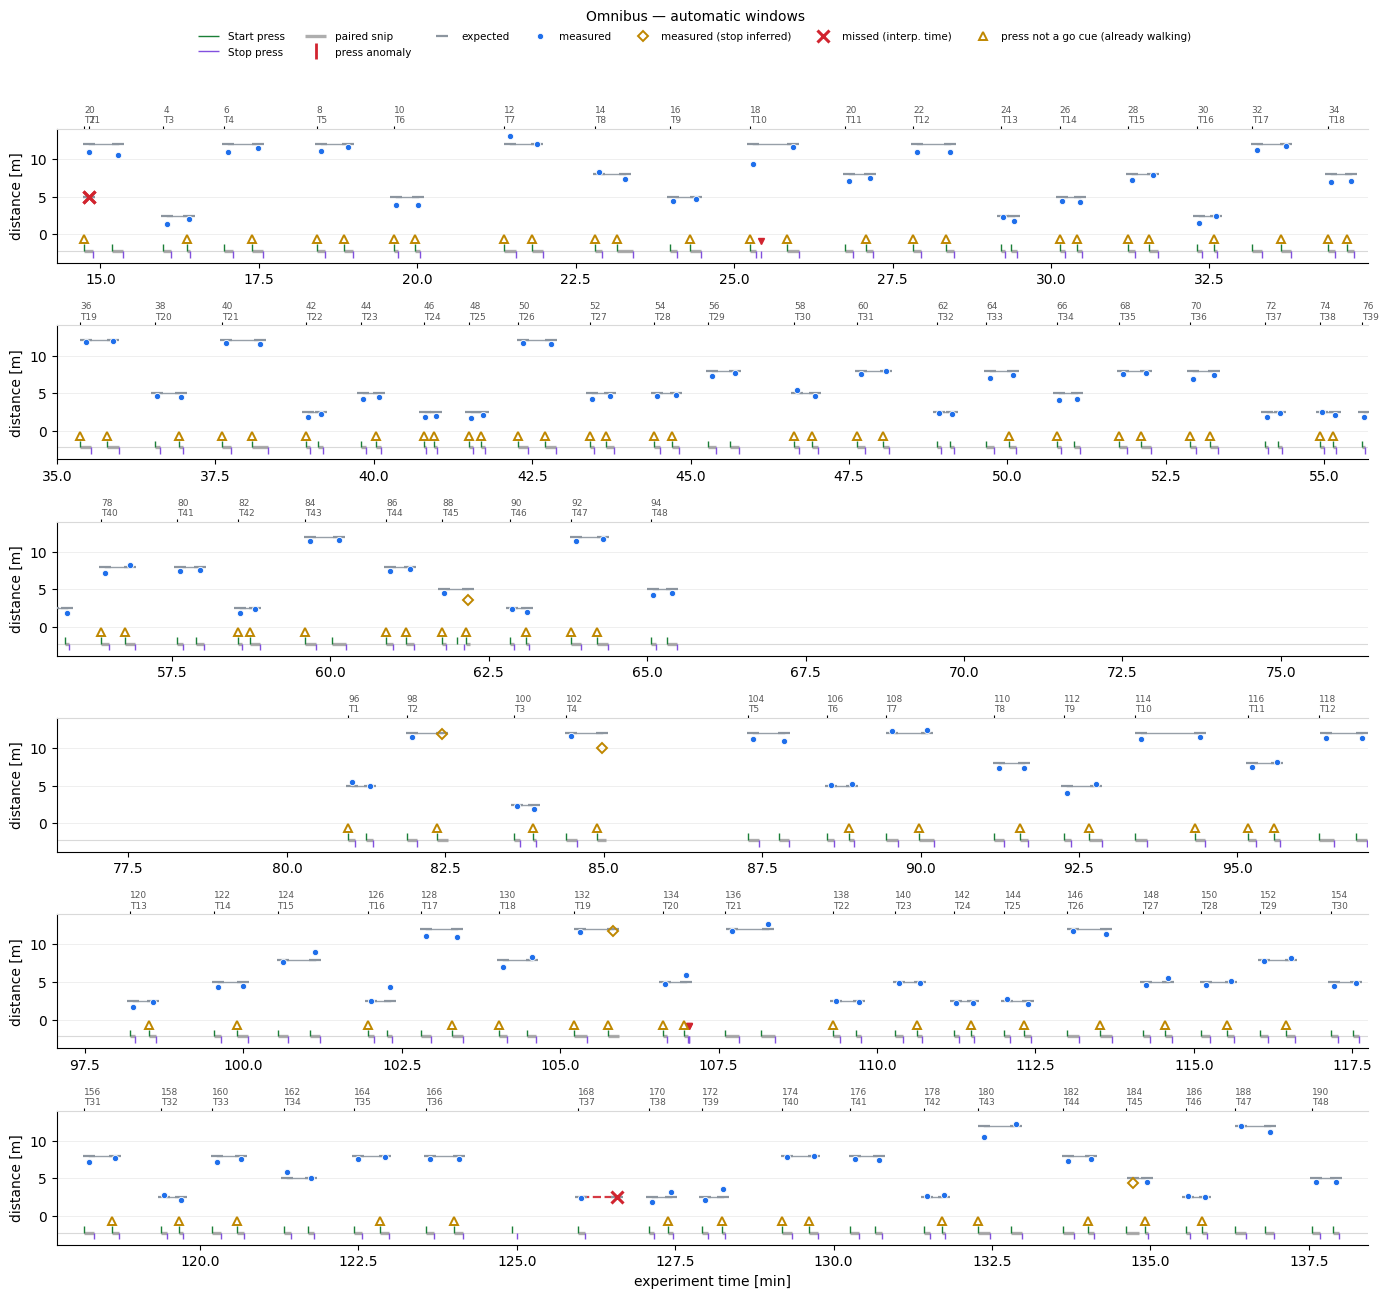

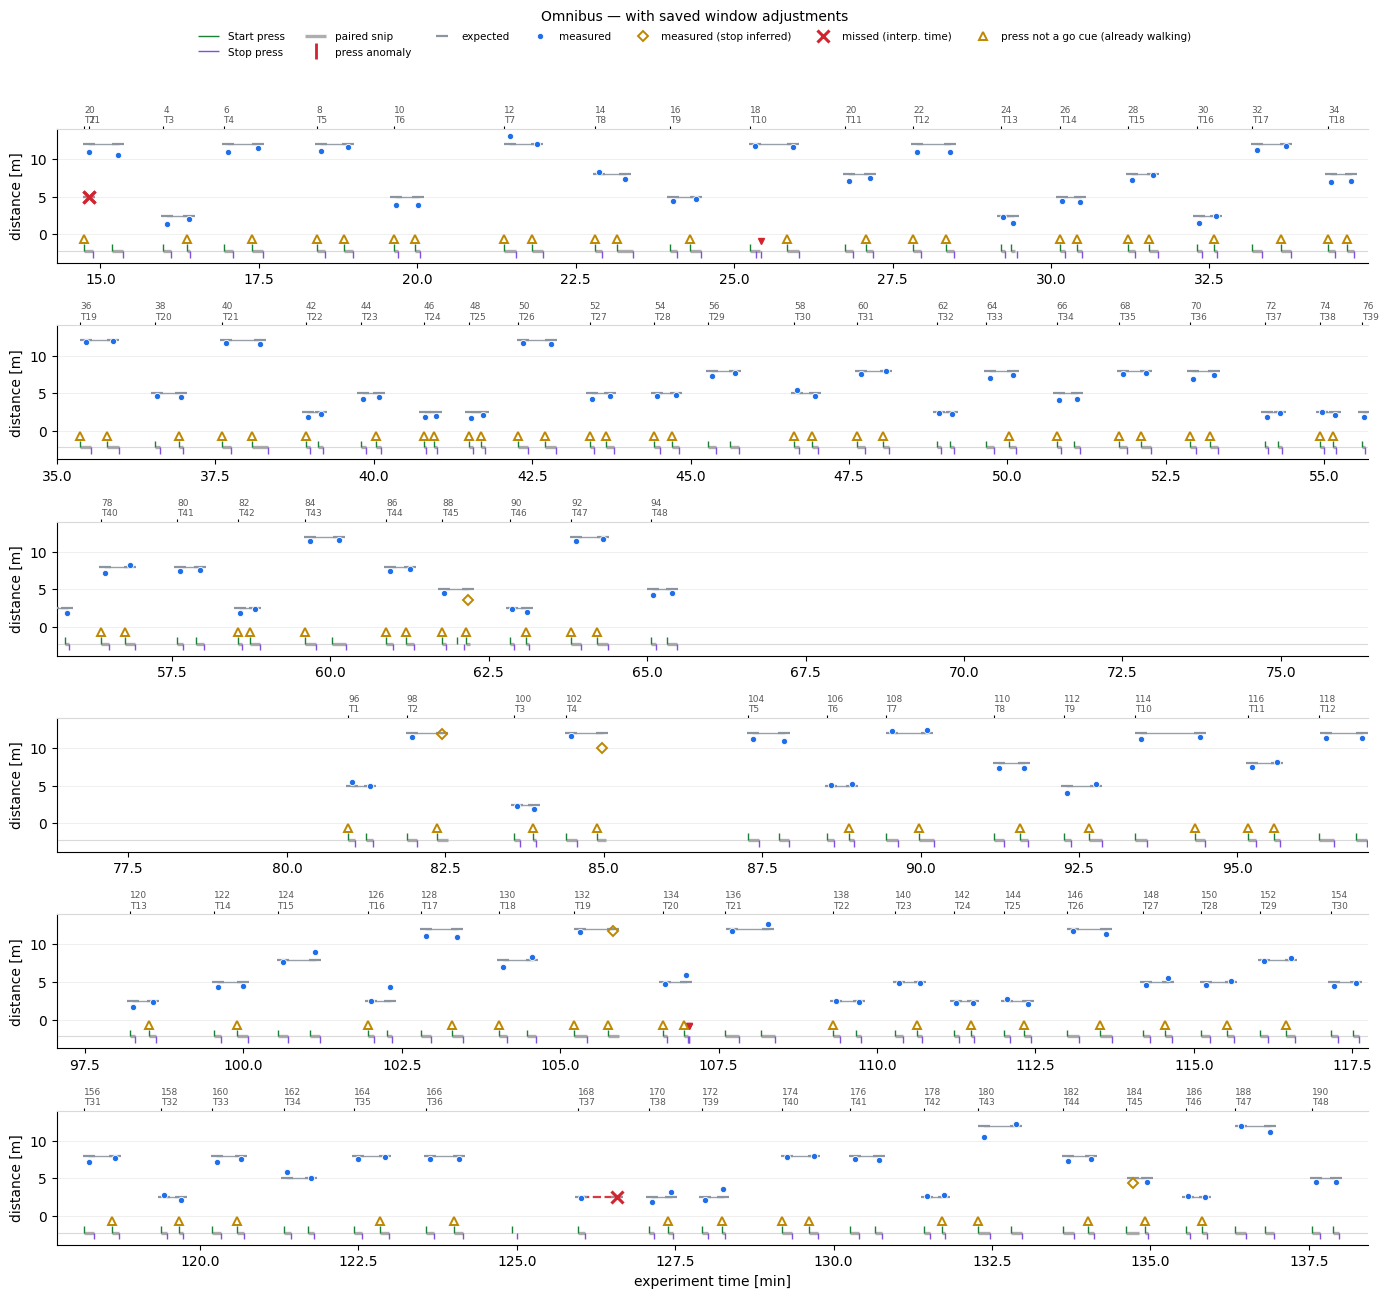

In [21]:
# H — automatic vs corrected: per-bout distance changes + both omnibus figures.
from IPython.display import display
from brock_functions import corrected_alignment, manual_changes
# like rerunning G with []: save the open editors' finished edits, close them
if 'scoring' in dir():
    scoring.close_editors()
plt.close('all')          # e.g. G1's widget check - keep it out of H's output
%matplotlib inline

aligned = corrected_alignment(feet, res['aligned'], RESCORE_CSV)
changes = manual_changes(res['aligned'], aligned)
OMNIBUS_DIR = os.path.join(os.path.dirname(H5_FILE), 'figures', SESSION_TAG)
os.makedirs(OMNIBUS_DIR, exist_ok=True)

fig_auto, _, _ = plot_omnibus(feet, events, res, report=report, rows=6)
path = os.path.join(OMNIBUS_DIR, f'brock_{SESSION_TAG}_omnibus_auto.svg')
fig_auto.savefig(path); print('saved', path)
if changes.empty:
    print('No saved corrections yet - fix bouts in G first '
          '(no omnibus_plus_manual figure written).')
else:
    print(f"{len(changes)} corrected bouts in trials "
          f"{sorted(changes['trial'].astype(int).unique())} "
          '(automatic_m is blank for recovered missed bouts)')
    display(changes.round(3))
    fig_corrected, _, _ = plot_omnibus(feet, events, res, aligned=aligned,
                                       report=report, rows=6,
                                       refresh_distances=False)
    path = os.path.join(OMNIBUS_DIR, f'brock_{SESSION_TAG}_omnibus_plus_manual.svg')
    fig_corrected.savefig(path); print('saved', path)
plt.show()


## I. Student playground — the three data types

Everything in this notebook is functions applied to **three kinds of data**.
If you are comfortable with these, you can re-analyse anything:

1. **Raw IMU recordings** — `feet` is a plain dict `{label -> ImuRecording}`
   (`'left_foot_a'`, `'right_foot_b'`, ...). An `ImuRecording` holds the gyro
   `Wb` (rad/sample), the accelerometer `Ab` (m/s²) and the sample `period`
   (s); `rec[a:b]` slices it like a list. Every trajectory, footfall and speed
   in this notebook is *derived* from these two signals.
2. **Tables** — `conditions` (one row per trial: distance, package, pose,
   experimenter notes) and `aligned` (one row per expected bout: when it
   happened, measured distance, who walked). Both are ordinary pandas
   DataFrames: filter, merge, group, plot.
3. **Rescore controllers** — the return value of `manual_correct()`: one
   object per inspected trial-rep that knows its window, the current bout
   spans and any rescores you clicked. `print()` one to see its state.

The cells below poke at each in turn — copy, edit and re-run them freely.

None of this needs memorizing — human working memory holds ~7 items, and these
objects hold far more. Cell (0) below shows the three introspection patterns
(`list(d)` / `.items()` for dicts, `vars(obj)` for objects, `.dtypes`/`.head()`
for tables) that let you ask *any* variable what it contains.


In [ ]:
# --- 0) don't memorize - ask the object what it contains --------------------
# Human working memory holds ~7 items; this notebook's objects hold far more.
# So never try to remember what is inside something - ASK it. Three patterns
# cover every named variable in this notebook:

# (a) a DICT, like `feet`: list its keys, or loop over key -> value pairs
print('feet is a', type(feet).__name__, 'with keys:', list(feet))
for name, rec in feet.items():
    print(f'   {name}: {len(rec)} samples @ {1/rec.period:.0f} Hz')

# (b) an OBJECT, like one ImuRecording: vars(obj) is a dict of its fields.
# Print names + types + shapes instead of the values (arrays are huge):
rec = feet['left_foot_a']
print('\none ImuRecording contains:')
for field, value in vars(rec).items():
    desc = getattr(value, 'shape', None) or type(value).__name__
    print(f'   rec.{field:22s} {desc}')
# (for anything else: dir(obj) lists methods too, help(obj) prints the docs)

# (c) a DataFrame, like `aligned` or `conditions`: .columns/.dtypes name the
# columns, .head() peeks at rows, .describe() summarizes numeric columns
print('\naligned columns:'); print(aligned.dtypes.to_string())
aligned.head(3)


In [ ]:
# --- 1) raw IMU data: pick a bout, look at the actual signals ---------------
rec = feet['left_foot_a']
print(f"left_foot_a: {len(rec)} samples @ {1/rec.period:.0f} Hz "
      f"({len(rec)*rec.period/60:.1f} min of recording)")

bout = aligned.dropna(subset=['start_s']).iloc[0]      # first scored bout
j0, j1 = int(bout.start_s / rec.period), int(bout.stop_s / rec.period)
piece = rec[j0:j1]                                     # slicing = new recording
t = np.arange(len(piece)) * rec.period

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].plot(t, np.linalg.norm(piece.Ab, axis=1), lw=0.6)
axes[0].set_ylabel('|A| [m/s²]')
axes[1].plot(t, np.linalg.norm(piece.Wb, axis=1) / rec.period, lw=0.6)
axes[1].set(ylabel='|gyro| [rad/s]', xlabel='time in bout [s]')
fig.suptitle(f"trial {bout.trial:.0f} rep {bout.rep:.0f} bout {bout.bout:.0f}: "
             f"raw left_foot_a signals")
plt.show()


In [ ]:
# --- 2) re-run the mechanization yourself -----------------------------------
# compute_position_two_imus integrates gyro + accel into foot trajectories,
# applying zero-velocity updates at every detected stance. It returns one
# FootTrajectory per foot: .P (position, m), .Vm (speed, m/s), .FF_walking
# (footfall mask), .euler ... — this is the engine under every figure above.
suffix = str(bout.walker)[-1]          # 'a' or 'b': who walked this bout
L = feet[f'left_foot_{suffix}'][j0:j1]
R = feet[f'right_foot_{suffix}'][j0:j1]
left_info, right_info = imu.compute_position_two_imus(L.Wb, L.Ab, R.Wb, R.Ab,
                                                      L.period)

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].plot(t, left_info.Vm, lw=0.7, label='left')
axes[0].plot(t, right_info.Vm, lw=0.7, label='right')
axes[0].set_ylabel('foot speed [m/s]'); axes[0].legend()
axes[1].plot(t, np.linalg.norm(left_info.P[:, :2] - left_info.P[0, :2], axis=1),
             lw=0.8, label='left')
axes[1].plot(t, np.linalg.norm(right_info.P[:, :2] - right_info.P[0, :2], axis=1),
             lw=0.8, label='right')
axes[1].set(ylabel='distance from start [m]', xlabel='time in bout [s]')
plt.show()
print(f"net horizontal travel: "
      f"left {np.linalg.norm(left_info.P[-1,:2]-left_info.P[0,:2]):.2f} m, "
      f"right {np.linalg.norm(right_info.P[-1,:2]-right_info.P[0,:2]):.2f} m "
      f"(trial table says {bout.distance_m} m)")


In [ ]:
# --- 3) tables: merge results with conditions, plot anything vs anything ----
# `aligned` already carries distance_m/package per bout; the merge adds the
# hand-off pose and the experimenter's per-rep notes from `conditions`.
table = (aligned.dropna(subset=['start_s'])
         .merge(conditions[['trial', 'pose', 'rep1_status', 'rep2_status']],
                on='trial'))
# crude bout-average speed: walked distance over the whole scored window
# (includes box handling — the per-STEP speeds in the figures are the real
# gait measure; this is just an easy table exercise)
table['bout_speed_mps'] = table['measured_m'] / table['duration_s']

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
table.boxplot(column='bout_speed_mps', by='distance_m', ax=axes[0])
table.boxplot(column='bout_speed_mps', by='pose', ax=axes[1])
for ax in axes:
    ax.set_ylabel('bout speed [m/s]'); ax.set_title('')
fig.suptitle('bout-average speed by condition')
plt.tight_layout(); plt.show()

table.groupby('distance_m')['bout_speed_mps'].agg(['mean', 'std', 'count']).round(2)


In [ ]:
# --- 4) the per-trial inspection figure, on demand --------------------------
# inspect_snipped_trial draws ONE trial's full figure (all matched bouts) and
# RETURNS the matplotlib Figure: grey pre-walk accel context, the Start/Stop
# button presses as vertical lines, and the reaction time / duration written
# on each bout. Change the trial number and re-run. Full details:
# help(inspect_snipped_trial)
from brock_functions import inspect_snipped_trial

fig = inspect_snipped_trial(feet, aligned, trial=5, session_tag=SESSION_TAG,
                            prefix_seconds=5.0)


In [ ]:
# --- 5) rescore controllers (the figures opened in section G) ---------------
# Each open editor is a live object that knows its state - print one to see
# it. scoring.corrected is the table with every saved correction applied.
if 'scoring' in dir() and scoring.editors:
    for c in scoring.editors:
        print(c)          # trial/rep, shown window/bouts, your edits
    print(scoring)
else:
    print('no open editors - run G2 or G3 with a (trial, rep) pair first')

In [ ]:
# --- Colab only: download everything this notebook produced -----------------
# Zips the cached tables + this session's figures (they live in the Colab VM,
# which is wiped when the session ends) and hands the zip to your browser.
# No Google permissions involved. A no-op when running locally.
if IN_COLAB:
    import zipfile
    from google.colab import files
    zpath = f'/content/brock_{SESSION_TAG}_results.zip'
    with zipfile.ZipFile(zpath, 'w', zipfile.ZIP_DEFLATED) as z:
        for sub in ('cached data', 'figures', 'figure'):     # outputs only, not the .h5
            for root, _, fns in os.walk(os.path.join(DATA_DIR, sub)):
                for fn in fns:
                    p = os.path.join(root, fn)
                    z.write(p, os.path.relpath(p, DATA_DIR))
    files.download(zpath)
else:
    print('running locally - results are already in', os.path.dirname(H5_FILE))
